Import required libraries for data analysis and visualization

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (2).csv


In [36]:
# Load the dataset
df = pd.read_csv("StudentsPerformance.csv")

# Display first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [37]:
# Get dataset shape (rows and columns)
df.shape

(1000, 8)

In [38]:
# View column names
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [39]:
# Check data types
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [40]:
# Get general information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [41]:
# Get statistical summary of numerical columns
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [42]:
# Check for missing values
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [43]:
# Create a copy of dataset
df2 = df.copy()

In [44]:
# Introduce missing values artificially in math score
df2.loc[0:9, 'math score'] = np.nan

In [45]:
# Verify missing values
df2.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,10
reading score,0
writing score,0


In [46]:
# Remove rows with missing values
df_drop = df2.dropna()
df_drop.shape

(990, 8)

In [47]:
# Fill missing values with mean
df_mean = df2.copy()
df_mean['math score'] = df_mean['math score'].fillna(df_mean['math score'].mean())
df_mean.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [48]:
# Fill missing values with median
df_median = df2.copy()
df_median['math score'] = df_median['math score'].fillna(df_median['math score'].median())
df_median.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


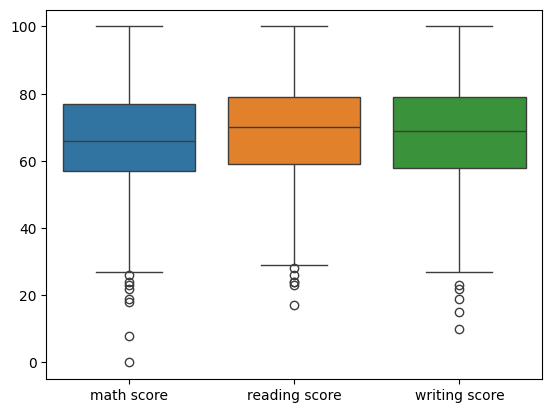

In [49]:
# Visualize outliers using boxplot
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.show()

In [50]:
# Calculate IQR for math score
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['math score'] < lower_bound) | (df['math score'] > upper_bound)]
outliers

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38
787,female,group B,some college,standard,none,19,38,32
842,female,group B,high school,free/reduced,completed,23,44,36
980,female,group B,high school,free/reduced,none,8,24,23


**Outliers were detected using the IQR method and removed to improve data quality.**

In [51]:
# Remove outliers using IQR boundaries
df_no_outliers = df[(df['math score'] >= lower_bound) & (df['math score'] <= upper_bound)]
df_no_outliers.shape

(992, 8)

In [52]:
# Import MinMaxScaler for normalization
from sklearn.preprocessing import MinMaxScaler

In [53]:
# Initialize scaler and create a copy of the dataset
scaler = MinMaxScaler()
df_minmax = df.copy()

# Apply Min-Max normalization to scale values between 0 and 1
df_minmax[['math score', 'reading score', 'writing score']] = scaler.fit_transform(
    df_minmax[['math score', 'reading score', 'writing score']]
)

df_minmax.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.72,0.662651,0.711111
1,female,group C,some college,standard,completed,0.69,0.879518,0.866667
2,female,group B,master's degree,standard,none,0.90,0.939759,0.922222
3,male,group A,associate's degree,free/reduced,none,0.47,0.481928,0.377778
4,male,group C,some college,standard,none,0.76,0.734940,0.722222


**Min-Max normalization scales the data to a range between 0 and 1, making features comparable.**

In [54]:
# Import StandardScaler for standardization
from sklearn.preprocessing import StandardScaler

In [55]:
# Initialize scaler and create a copy of dataset
scaler = StandardScaler()
df_zscore = df.copy()

# Apply Z-score standardization (mean = 0, std = 1)
df_zscore[['math score', 'reading score', 'writing score']] = scaler.fit_transform(
    df_zscore[['math score', 'reading score', 'writing score']]
)

df_zscore.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.390024,0.193999,0.391492
1,female,group C,some college,standard,completed,0.192076,1.427476,1.313269
2,female,group B,master's degree,standard,none,1.577711,1.770109,1.642475
3,male,group A,associate's degree,free/reduced,none,-1.259543,-0.833899,-1.583744
4,male,group C,some college,standard,none,0.653954,0.605158,0.457333


**Z-score standardization transforms the data to have a mean of 0 and standard deviation of 1.**

In [56]:
# Calculate correlation matrix between numerical features
corr = df[['math score', 'reading score', 'writing score']].corr()
corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


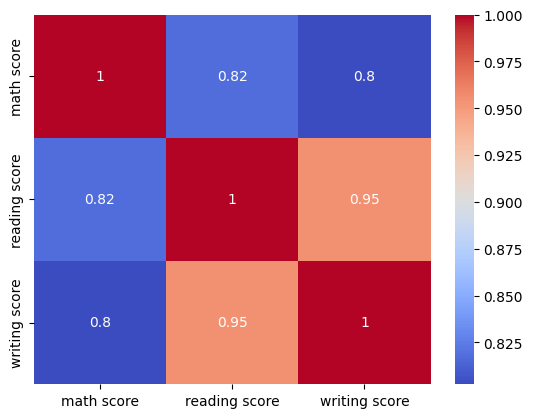

In [57]:
# Visualize correlation using heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**The heatmap shows a strong positive relationship between math, reading, and writing scores.**

**Conclusion**

In this lab, data quality was assessed by identifying missing values and outliers. Different preprocessing techniques such as mean imputation, normalization, and standardization were applied to improve data quality. The results show that preprocessing plays an important role in preparing data for analysis.